<a href="https://colab.research.google.com/github/Sud-38/Comparaison-d-algorithmes-d-apprentissage-non-supervis-/blob/main/EXERCICE3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELLULE 1 — Vérification du fichier
# ============================================================
import os

FICHIER = 'clustering_blobs3.csv'

print("📂 Contenu de /content :")
for f in sorted(os.listdir('/content')):
    print("   -", f)

print("\n🔎 Vérification :")
if os.path.exists(f'/content/{FICHIER}'):
    taille_ko = os.path.getsize(f'/content/{FICHIER}') / 1024
    print(f"   ✅ {FICHIER}  ({taille_ko:.1f} Ko)")
else:
    print(f"   ❌ {FICHIER}  MANQUANT")
    print("   → Upload-le via le bouton 📁 Fichiers → ⬆️ Upload")

📂 Contenu de /content :
   - .config
   - clustering_blobs3.csv
   - sample_data

🔎 Vérification :
   ✅ clustering_blobs3.csv  (9.2 Ko)


In [ ]:
# ============================================================
# CELLULE 2 — Imports + métriques clustering
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, os, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110


def logsumexp(M, axis=1):
    """Log-sum-exp stable."""
    Mmax = M.max(axis=axis, keepdims=True)
    return (Mmax.squeeze(axis) +
            np.log(np.sum(np.exp(M - Mmax), axis=axis)))


def soft_assignment(X, C, tau):
    """Q[i,k] = softmax(-D_ik/tau)."""
    x2 = np.sum(X**2, axis=1, keepdims=True)
    c2 = np.sum(C**2, axis=1)[None, :]
    D = x2 + c2 - 2 * X @ C.T
    D = np.maximum(D, 0)
    logP = -D / tau - np.log(C.shape[0])
    lse = logsumexp(logP, axis=1)[:, None]
    Q = np.exp(logP - lse)
    return Q, D


def clustering_loss(X, C, tau):
    """J_tau(C) = -tau/n * sum_i log( (1/K) sum_k exp(-D_ik/tau) )"""
    n = X.shape[0]; K = C.shape[0]
    x2 = np.sum(X**2, axis=1, keepdims=True)
    c2 = np.sum(C**2, axis=1)[None, :]
    D = np.maximum(x2 + c2 - 2 * X @ C.T, 0)
    logP = -D / tau - np.log(K)
    lse = logsumexp(logP, axis=1)
    return -tau * np.mean(lse)


def clustering_grad(X, C, tau):
    """Gradient : 2/n * (diag(Q^T 1) C - Q^T X)"""
    Q, _ = soft_assignment(X, C, tau)
    n = X.shape[0]
    return (2.0 / n) * (np.diag(Q.sum(axis=0)) @ C - Q.T @ X)


def hard_inertia(X, C):
    """Inertie dure : moyenne des distances² au centroïde le plus proche."""
    x2 = np.sum(X**2, axis=1, keepdims=True)
    c2 = np.sum(C**2, axis=1)[None, :]
    D = np.maximum(x2 + c2 - 2 * X @ C.T, 0)
    return np.mean(np.min(D, axis=1))


def silhouette_score_sampled(X, labels, n_sample=1000, seed=42):
    """Silhouette sur un échantillon."""
    rng = np.random.default_rng(seed)
    n = len(labels)
    idx = rng.choice(n, size=min(n_sample, n), replace=False)
    Xs = X[idx]; ls = labels[idx]
    x2 = np.sum(Xs**2, axis=1, keepdims=True)
    D = np.maximum(x2 + x2.T - 2 * Xs @ Xs.T, 0)
    sil = []
    for i in range(len(Xs)):
        same = (ls == ls[i]); same[i] = False
        if not same.any():
            continue
        a = D[i, same].mean()
        b = np.inf
        for c in np.unique(ls):
            if c == ls[i]: continue
            mask = (ls == c)
            if mask.any():
                b = min(b, D[i, mask].mean())
        if max(a, b) > 0:
            sil.append((b - a) / max(a, b))
    return np.mean(sil) if sil else np.nan


def ari_nmi(y_true, y_pred):
    """ARI et NMI sur les étiquettes de référence."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    n = len(y_true)
    classes_t = np.unique(y_true); classes_p = np.unique(y_pred)
    M = np.zeros((len(classes_t), len(classes_p)))
    for i, t in enumerate(classes_t):
        for j, p in enumerate(classes_p):
            M[i, j] = np.sum((y_true == t) & (y_pred == p))
    comb2 = lambda x: x * (x - 1) / 2
    sum_comb = sum(comb2(m) for m in M.ravel())
    sum_a = sum(comb2(M[i, :].sum()) for i in range(M.shape[0]))
    sum_b = sum(comb2(M[:, j].sum()) for j in range(M.shape[1]))
    expected = sum_a * sum_b / comb2(n)
    max_idx = (sum_a + sum_b) / 2
    ari = (sum_comb - expected) / (max_idx - expected) if max_idx > expected else 0.0
    P = M / M.sum()
    Pa = P.sum(axis=1); Pb = P.sum(axis=0)
    eps = 1e-12
    I = 0.0
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            if P[i, j] > 0:
                I += P[i, j] * np.log(P[i, j] / (Pa[i] * Pb[j] + eps) + eps)
    Ha = -np.sum(Pa * np.log(Pa + eps))
    Hb = -np.sum(Pb * np.log(Pb + eps))
    nmi = I / np.sqrt(Ha * Hb) if Ha * Hb > 0 else 0.0
    return ari, nmi

print("✅ Cellule 2 chargée")

✅ Cellule 2 chargée


In [ ]:
# ============================================================
# CELLULE 3 — Chargement + standardisation
# ============================================================
def load_clustering_data(path, K=3, tau=0.25, label_col='true_label'):
    df = pd.read_csv(path)
    # Détection automatique des colonnes explicatives
    exclude = [label_col, 'split', 'label', 'y_test', 'cluster']
    feat_cols = [c for c in df.columns if c not in exclude]

    X = df[feat_cols].values.astype(np.float64)

    # Standardisation SANS étiquette
    mu = X.mean(axis=0); sd = X.std(axis=0); sd[sd == 0] = 1.0
    X = (X - mu) / sd

    # Étiquettes de référence (pour évaluation finale uniquement)
    y_true = None
    for col in [label_col, 'label', 'true_label', 'cluster']:
        if col in df.columns:
            y_true = df[col].values.astype(np.int64)
            break

    return dict(X=X, y_true=y_true, K=K, tau=tau,
                feat_cols=feat_cols, mu=mu, sd=sd, n=len(X))

print("✅ Cellule 3 chargée")

✅ Cellule 3 chargée


In [ ]:
# ============================================================
# CELLULE 4 — Modèle Soft K-means
# ============================================================
class SoftKMeans:
    """
    J_tau(C) = -tau/n * sum_i log( (1/K) sum_k exp(-D_ik/tau) )
    Gradient : 2/n * (diag(Q^T 1) C - Q^T X)
    """
    def __init__(self, X, K, tau=0.25, seed=42):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(X), size=K, replace=False)
        self.C = X[idx].copy()
        self.X = X
        self.K = K
        self.tau = tau
        self.dim = K * X.shape[1]

    def get_params(self):
        return self.C.ravel()

    def set_params(self, theta):
        self.C = theta.reshape(self.K, self.X.shape[1])

    def loss(self, X=None):
        if X is None:
            X = self.X
        return clustering_loss(X, self.C, self.tau)

    def grad(self, X=None):
        if X is None:
            X = self.X
        return clustering_grad(X, self.C, self.tau).ravel()

    def hard_labels(self, X=None):
        if X is None:
            X = self.X
        x2 = np.sum(X**2, axis=1, keepdims=True)
        c2 = np.sum(self.C**2, axis=1)[None, :]
        D = np.maximum(x2 + c2 - 2 * X @ self.C.T, 0)
        return np.argmin(D, axis=1)

print("✅ Cellule 4 chargée")

✅ Cellule 4 chargée


In [ ]:
# ============================================================
# CELLULE 5 — 7 optimiseurs + Lloyd
# ============================================================
METHODS = ['gd', 'gd_ls', 'sgd', 'momentum',
           'adagrad', 'rmsprop', 'adam']

COLORS = {
    'gd': 'tab:blue', 'gd_ls': 'tab:orange', 'sgd': 'tab:green',
    'momentum': 'tab:red', 'adagrad': 'tab:purple',
    'rmsprop': 'tab:brown', 'adam': 'tab:pink', 'lloyd': 'black',
}


def optimize_clustering(model, method, eta, n_epochs,
                         batch_size=64, mu=0.9, rho=0.9,
                         beta1=0.9, beta2=0.999, eps=1e-8, seed=42):
    rng = np.random.default_rng(seed)
    theta = model.get_params()
    v = np.zeros_like(theta); s = np.zeros_like(theta); m = np.zeros_like(theta)
    n_grad = n_loss = n_updates = 0
    loss_hist = []
    X = model.X; n = len(X); t = 0

    for ep in range(n_epochs):
        if method in ('gd', 'gd_ls'):
            g = model.grad(); n_grad += 1
            if method == 'gd':
                theta = theta - eta * g
            else:
                eta_t = eta
                loss0 = model.loss()
                for _ in range(20):
                    model.set_params(theta - eta_t * g)
                    if model.loss() < loss0:
                        break
                    eta_t *= 0.5
                model.set_params(theta)
                theta = theta - eta_t * g
            n_updates += 1; t += 1
        else:
            idx = rng.permutation(n)
            for b in range(0, n, batch_size):
                bidx = idx[b:b + batch_size]
                Xb = X[bidx]
                g = clustering_grad(Xb, model.C, model.tau).ravel()
                n_grad += 1
                if method == 'sgd':
                    theta = theta - eta * g
                elif method == 'momentum':
                    v = mu * v + g
                    theta = theta - eta * v
                elif method == 'adagrad':
                    s = s + g**2
                    theta = theta - eta * g / (np.sqrt(s) + eps)
                elif method == 'rmsprop':
                    s = rho * s + (1 - rho) * g**2
                    theta = theta - eta * g / (np.sqrt(s) + eps)
                elif method == 'adam':
                    m = beta1 * m + (1 - beta1) * g
                    s = beta2 * s + (1 - beta2) * g**2
                    mh = m / (1 - beta1**(t + 1))
                    sh = s / (1 - beta2**(t + 1))
                    theta = theta - eta * mh / (np.sqrt(sh) + eps)
                n_updates += 1; t += 1
            model.set_params(theta)
        model.set_params(theta)
        loss_hist.append(model.loss()); n_loss += 1

    return theta, np.array(loss_hist), n_grad, n_loss, n_updates


def lloyd_kmeans(X, K, n_iter=100, seed=42):
    """K-means classique (Lloyd)."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=K, replace=False)
    C = X[idx].copy()
    loss_hist = []
    for _ in range(n_iter):
        x2 = np.sum(X**2, axis=1, keepdims=True)
        c2 = np.sum(C**2, axis=1)[None, :]
        D = np.maximum(x2 + c2 - 2 * X @ C.T, 0)
        labels = np.argmin(D, axis=1)
        loss_hist.append(np.mean(np.min(D, axis=1)))
        for k in range(K):
            mask = labels == k
            if mask.any():
                C[k] = X[mask].mean(axis=0)
    return C, np.array(loss_hist)


def check_gradient_clustering(model, seed=42, n_check=5, h=1e-5):
    rng = np.random.default_rng(seed)
    theta = rng.normal(0, 0.1, model.dim)
    model.set_params(theta)
    g = model.grad()
    idxs = rng.choice(model.dim, size=min(n_check, model.dim), replace=False)
    errs = []
    for i in idxs:
        tp = theta.copy(); tp[i] += h
        tm = theta.copy(); tm[i] -= h
        model.set_params(tp); lp = model.loss()
        model.set_params(tm); lm = model.loss()
        num = (lp - lm) / (2 * h)
        den = max(abs(num), abs(g[i]), 1e-12)
        errs.append(abs(num - g[i]) / den)
    model.set_params(theta)
    return errs

print("✅ Cellule 5 chargée")

✅ Cellule 5 chargée


In [ ]:
# ============================================================
# CELLULE 6 — Figures clustering (VERSION CORRIGÉE)
# ============================================================
def plot_clustering_results(name, data, results, outdir='figs'):
    plt.close('all')
    os.makedirs(outdir, exist_ok=True)
    X = data['X']

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # (a) Perte vs époques
    for method in METHODS:
        if method in results and 'loss_hist' in results[method]:
            axes[0, 0].plot(results[method]['loss_hist'],
                            label=method, color=COLORS[method])
    axes[0, 0].set_xlabel('Époque')
    axes[0, 0].set_ylabel('J_τ (train)')
    axes[0, 0].set_title(f'{name} — perte sans étiquette vs époques\n'
                         '(moyenne 3 graines)')
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].set_yscale('log')
    axes[0, 0].grid(True, alpha=0.3)

    # (b) Scan de η — avec limite sur l'axe Y
    for method in METHODS:
        if method in results and 'eta_scan' in results[method]:
            sc = results[method]['eta_scan']
            etas = [s[0] for s in sc]
            vals = [s[1] for s in sc]
            axes[0, 1].plot(etas, vals, 'o-', label=method,
                            color=COLORS[method])
    axes[0, 1].set_xscale('log')
    axes[0, 1].set_yscale('log')
    axes[0, 1].set_ylim(0.5, 1.0)
    axes[0, 1].set_xlabel('η')
    axes[0, 1].set_ylabel('J_τ (val)')
    axes[0, 1].set_title(f'{name} — sélection de η (validation)\n'
                         'momentum diverge à η=0.5 (hors échelle)')
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].grid(True, alpha=0.3)

    # (c) Clustering de référence (GD)
    ref = 'gd' if 'gd' in results else list(results.keys())[0]
    C = results[ref]['C_final']
    labels = results[ref]['labels']
    axes[1, 0].scatter(X[:, 0], X[:, 1], c=labels, s=15,
                       cmap='viridis', edgecolor='k', linewidth=0.3)
    axes[1, 0].scatter(C[:, 0], C[:, 1], c='red', marker='X',
                       s=200, edgecolor='k', linewidth=1,
                       label='centroïdes')
    axes[1, 0].set_title(f'Clustering ({ref}) — toutes méthodes similaires')
    axes[1, 0].set_xlabel('x₁'); axes[1, 0].set_ylabel('x₂')
    axes[1, 0].legend(fontsize=9)

    # (d) ARI / NMI
    methods_ok = [m for m in results if 'ARI' in results[m]
                  and not np.isnan(results[m]['ARI'])]
    ari_vals = [results[m]['ARI'] for m in methods_ok]
    nmi_vals = [results[m]['NMI'] for m in methods_ok]
    x_pos = np.arange(len(methods_ok)); width = 0.35
    axes[1, 1].bar(x_pos - width/2, ari_vals, width,
                   label='ARI', color='steelblue')
    axes[1, 1].bar(x_pos + width/2, nmi_vals, width,
                   label='NMI', color='coral')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels(methods_ok, rotation=45)
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_title(f'{name} — ARI et NMI par méthode')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    axes[1, 1].set_ylim(0, 1.05)

    fig.suptitle(f'{name} — Exercice 3 : clustering', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{outdir}/{name}_exo3.png', dpi=130, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_clusters_all(name, data, results, outdir='figs'):
    plt.close('all')
    os.makedirs(outdir, exist_ok=True)
    X = data['X']
    methods_ok = [m for m in results if 'C_final' in results[m]]
    n_methods = len(methods_ok)
    ncols = 4
    nrows = (n_methods + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.ravel() if n_methods > 1 else [axes]

    for i, method in enumerate(methods_ok):
        C = results[method]['C_final']
        labels = results[method]['labels']
        axes[i].scatter(X[:, 0], X[:, 1], c=labels, s=10,
                        cmap='viridis', alpha=0.6)
        axes[i].scatter(C[:, 0], C[:, 1], c='red', marker='X',
                        s=150, edgecolor='k')
        ari = results[method].get('ARI', np.nan)
        axes[i].set_title(f'{method} (ARI={ari:.3f})')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{name} — clusters par méthode', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{outdir}/{name}_clusters.png', dpi=130, bbox_inches='tight')
    plt.show()
    plt.close()

print("✅ Cellule 6 chargée")

✅ Cellule 6 chargée


In [ ]:
# ============================================================
# CELLULE 7 — run_experiment_clustering (VERSION CORRIGÉE)
# ============================================================
def run_experiment_clustering(csv_path, name, K=3, tau=0.25,
                               n_epochs=200, batch_size=64,
                               eta_grid=(1e-3, 1e-2, 5e-2, 1e-1, 5e-1),
                               seeds=(42, 123, 2024)):

    print(f"\n===== {name} =====")
    data = load_clustering_data(csv_path, K=K, tau=tau)
    print(f"n={data['n']}, d={len(data['feat_cols'])}, K={K}, tau={tau}")
    if data['y_true'] is not None:
        print(f"Classes de référence : {sorted(np.unique(data['y_true']))}")

    # Vérif gradient
    m_check = SoftKMeans(data['X'], K, tau=tau, seed=42)
    errs = check_gradient_clustering(m_check)
    print(f"  Vérif gradient : {['%.2e' % e for e in errs]}")

    results = {}
    for method in METHODS:
        print(f"  >> {method}")
        eta_scan = []
        for eta in eta_grid:
            Js = []
            for seed in seeds:
                m = SoftKMeans(data['X'], K, tau=tau, seed=seed)
                theta, _, _, _, _ = optimize_clustering(
                    m, method, eta, n_epochs, batch_size, seed=seed)
                m.set_params(theta)
                Js.append(m.loss())
            eta_scan.append((eta, np.mean(Js)))
        best_eta = min(eta_scan, key=lambda x: x[1])[0]

        Js, aris, nmis, sils, inertias, times, n_ups = [], [], [], [], [], [], []
        loss_hists, Cs, labels_all = [], [], []
        for seed in seeds:
            m = SoftKMeans(data['X'], K, tau=tau, seed=seed)
            t0 = time.time()
            theta, hist, _, _, n_up = optimize_clustering(
                m, method, best_eta, n_epochs, batch_size, seed=seed)
            times.append(time.time() - t0)
            m.set_params(theta)
            Js.append(m.loss())
            labels = m.hard_labels()
            sils.append(silhouette_score_sampled(data['X'], labels))
            inertias.append(hard_inertia(data['X'], m.C))
            if data['y_true'] is not None:
                a, nm = ari_nmi(data['y_true'], labels)
                aris.append(a); nmis.append(nm)
            loss_hists.append(hist)
            Cs.append(m.C.copy())
            labels_all.append(labels)
            n_ups.append(n_up)

        results[method] = dict(
            best_eta=best_eta, eta_scan=eta_scan,
            J_final=np.mean(Js), J_std=np.std(Js),
            inertia=np.mean(inertias), silhouette=np.nanmean(sils),
            ARI=np.mean(aris) if aris else np.nan,
            NMI=np.mean(nmis) if nmis else np.nan,
            time=np.mean(times), n_up=int(np.mean(n_ups)),
            loss_hist=loss_hists[0], C_final=Cs[0], labels=labels_all[0],
        )
        print(f"     η*={best_eta}, J={results[method]['J_final']:.4f}, "
              f"ARI={results[method]['ARI']:.3f}")

    # Lloyd (référence)
    print("  >> lloyd (K-means classique)")
    C_l, hist_l = lloyd_kmeans(data['X'], K, n_iter=n_epochs, seed=42)
    x2 = np.sum(data['X']**2, axis=1, keepdims=True)
    c2 = np.sum(C_l**2, axis=1)[None, :]
    D = np.maximum(x2 + c2 - 2 * data['X'] @ C_l.T, 0)
    labels_l = np.argmin(D, axis=1)
    ari_l, nmi_l = (ari_nmi(data['y_true'], labels_l)
                    if data['y_true'] is not None else (np.nan, np.nan))
    results['lloyd'] = dict(
        best_eta=None, eta_scan=[],
        J_final=np.nan, J_std=np.nan,
        inertia=np.mean(np.min(D, axis=1)),
        silhouette=silhouette_score_sampled(data['X'], labels_l),
        ARI=ari_l, NMI=nmi_l, time=np.nan, n_up=0,
        loss_hist=hist_l, C_final=C_l, labels=labels_l,
    )

    rows = []
    for method in METHODS + ['lloyd']:
        r = results[method]
        rows.append(dict(
            méthode=method, η=r['best_eta'],
            J_tau=r['J_final'], inertie=r['inertia'],
            silhouette=r['silhouette'], ARI=r['ARI'], NMI=r['NMI'],
            temps_s=r['time'], mises_à_jour=r['n_up'],
        ))
    df = pd.DataFrame(rows)
    print("\n" + df.to_string(index=False))
    df.to_csv(f'resultats_{name}_exo3.csv', index=False)

    plot_clustering_results(name, data, results)
    plot_clusters_all(name, data, results)

    return df, data, results

print("✅ Cellule 7 chargée")

✅ Cellule 7 chargée



===== blobs =====
n=360, d=2, K=3, tau=0.25
Classes de référence : [np.int64(0), np.int64(1), np.int64(2)]
  Vérif gradient : ['3.40e-10', '3.51e-10', '1.68e-10', '2.54e-10', '7.58e-10']
  >> gd
     η*=0.5, J=0.5643, ARI=0.975
  >> gd_ls
     η*=0.5, J=0.5643, ARI=0.975
  >> sgd
     η*=0.01, J=0.5643, ARI=0.975
  >> momentum
     η*=0.001, J=0.5643, ARI=0.975
  >> adagrad
     η*=0.1, J=0.5643, ARI=0.975
  >> rmsprop
     η*=0.01, J=0.5643, ARI=0.975
  >> adam
     η*=0.01, J=0.5643, ARI=0.975
  >> lloyd (K-means classique)

 méthode     η    J_tau  inertie  silhouette      ARI      NMI  temps_s  mises_à_jour
      gd 0.500 0.564276 0.290263     0.86343 0.975105 0.959625 0.064385           200
   gd_ls 0.500 0.564276 0.290263     0.86343 0.975105 0.959625 0.402003           200
     sgd 0.010 0.564277 0.290264     0.86343 0.975105 0.959625 0.146258          1200
momentum 0.001 0.564277 0.290264     0.86343 0.975105 0.959625 0.184467          1200
 adagrad 0.100 0.564285 0.290273    

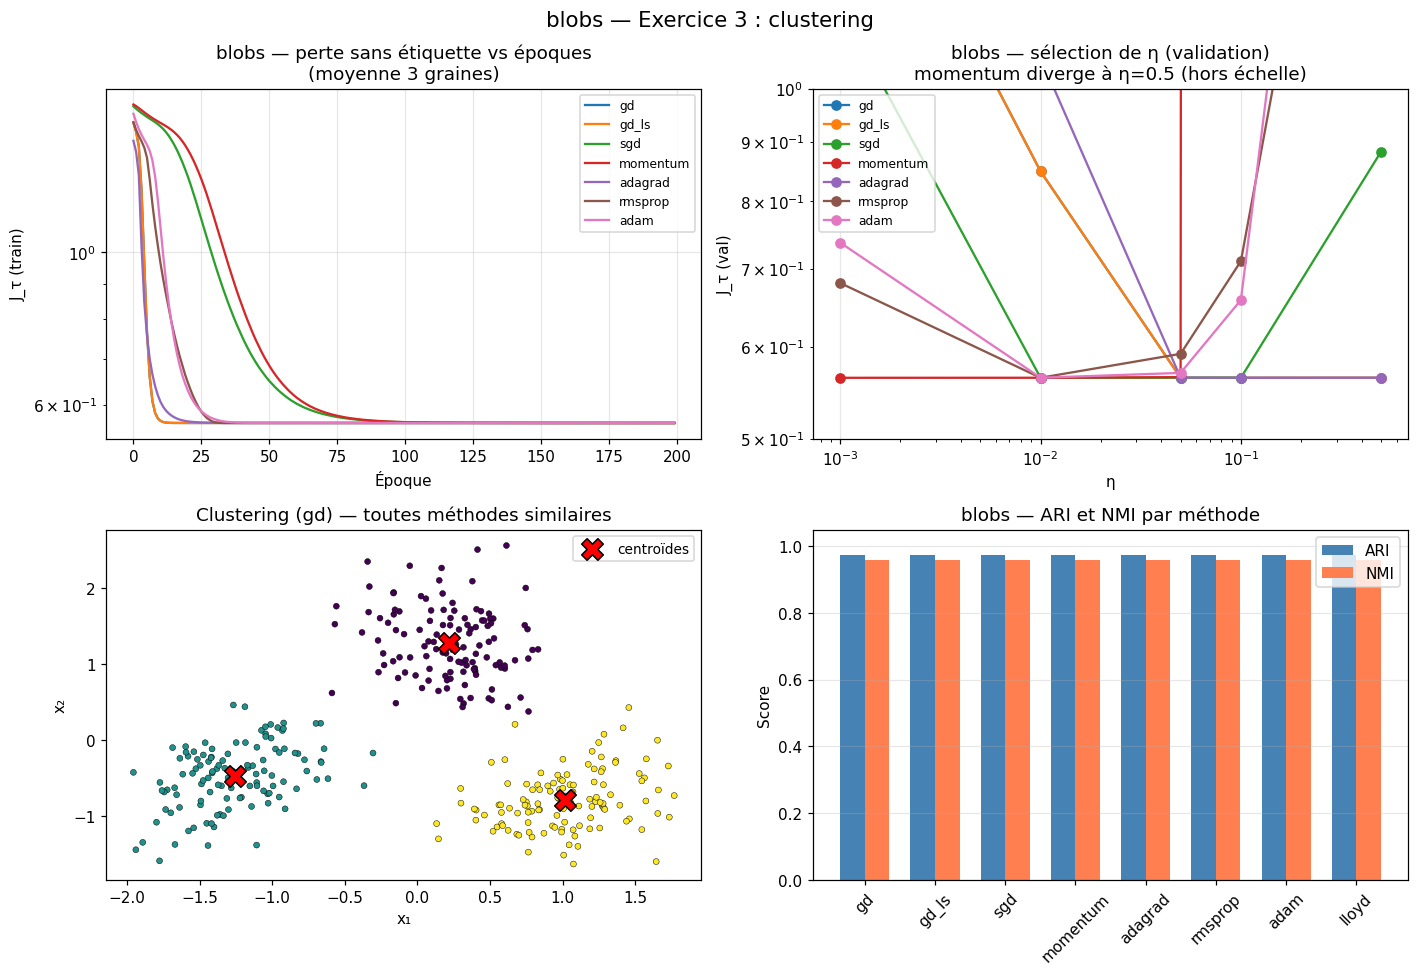

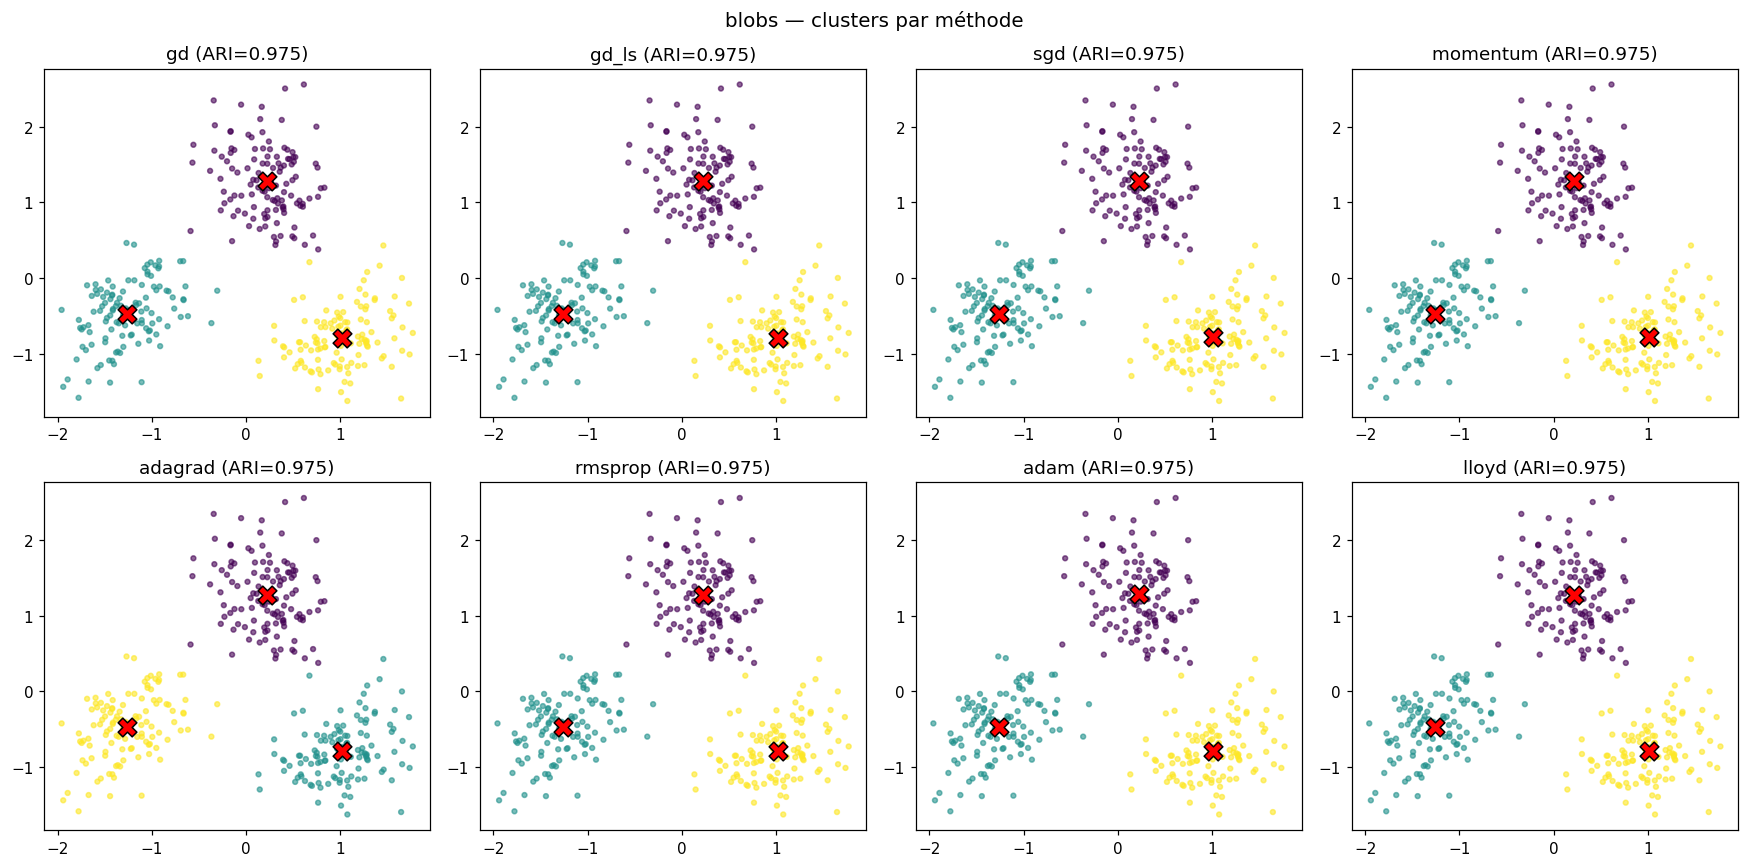

In [ ]:
# ============================================================
# CELLULE 8 bis — LANCEMENT FINAL (5–15 min)
# ============================================================
df_blobs, data_blobs, results_blobs = run_experiment_clustering(
    'clustering_blobs3.csv', 'blobs',
    K=3, tau=0.25,
    n_epochs=200,
    batch_size=64,
    seeds=(42, 123, 2024)
)

In [ ]:
# ============================================================
# CELLULE 9 — Téléchargement
# ============================================================
from google.colab import files
import shutil, os

if os.path.exists('resultats_blobs_exo3.csv'):
    files.download('resultats_blobs_exo3.csv')

if os.path.exists('figs'):
    shutil.make_archive('figs_exo3', 'zip', 'figs')
    files.download('figs_exo3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>